## Download genomes from GenBank, BLAST protein sequence and get coordinates of findings for AUGUSTUS

In [37]:
import pandas as pd
import subprocess
df = pd.read_csv('~/gpfs/NPM/genomes.txt', sep="\t")
df = df.drop_duplicates(subset='Organism Name', keep='first')


base_dir = "/home/ilnitsky/NPM/genomes/echinodermata"
results_dir = "/home/ilnitsky/NPM/results"
query_proteins = "/home/ilnitsky/NPM/NTerminalEchinodermata.fasta"

for index, row in df.iterrows():
    bioproject = row['Assembly BioProject Accession']
    assembly_accesion = row['Assembly Accession']
    assembly_name = row['Assembly Name']
    organism_name = row['Organism Name'].replace(' ', '_')
    genome_fna = f"{base_dir}/{organism_name}/ncbi_dataset/data/{assembly_accesion}/{assembly_accesion}_{assembly_name}_genomic.fna"
    print(organism_name, assembly_name, genome_fna)
    

    if not os.path.exists(f"{base_dir}/{organism_name}"):
        curl_command = f"""
                curl -o {base_dir}/{organism_name}.zip 'https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/{assembly_accesion}/download?include_annotation_type=GENOME_FASTA&include_annotation_type=GENOME_GFF&include_annotation_type=RNA_FASTA&include_annotation_type=CDS_FASTA&include_annotation_type=PROT_FASTA&include_annotation_type=SEQUENCE_REPORT&hydrated=FULLY_HYDRATED'
                unzip {base_dir}/{organism_name}.zip -d {base_dir}/{organism_name}
        """

        # esearch_command = f"""
        #     esearch -db bioproject -query \"{bioproject}\" | \
        #     elink -target nuccore | \
        #     efetch -format fasta > {genome_fna}
        #     """

        make_indexes_command = f"""
                makeblastdb -in {genome_fna} -dbtype nucl
                samtools faidx {genome_fna}
            """
    else:
        curl_command = f"ls {base_dir}/{organism_name}"
        make_indexes_command = f"ls {genome_fna}"
    
    blast_command = f"""
        tblastn -query {query_proteins} \
            -db {genome_fna}  \
            -outfmt 6 \
            -evalue 0.00001\
        | tee -a {results_dir}/blast_results.txt \
        | awk 'BEGIN{{OFS="\\t"}} {{ if ($9 < $10) {{start = $9 - 10000; end = $10 + 10000;}} else {{start = $10 - 15000; end = $9 + 15000;}} if (start < 0) start = 0;  print $2, start, end;}}' > {results_dir}/regions/{organism_name}.bed
        """
        
    extract_fasta_command = f"""
        bedtools getfasta -fi {genome_fna} -bed {results_dir}/regions/{organism_name}.bed -fo {results_dir}/extracted/{organism_name}.extracted.fasta
        """
    
    translate_in_6_frames_command = f"""
        transeq {results_dir}/extracted/{organism_name}.extracted.fasta {results_dir}/extracted/{organism_name}.aminoacid.extracted.fasta  -frame=6
    """

    augustus_CDS_command = f"""
        augustus --species=amphimedon {results_dir}/extracted/{organism_name}.extracted.fasta > {results_dir}/augustus/{organism_name}.augustus --AUGUSTUS_CONFIG_PATH=/home/ilnitsky/anaconda3/envs/npm/config/
        """

    hmmer_command = f"""
        hmmsearch --domtblout {results_dir}/hmmer/{organism_name}.C_term.txt ~/gpfs/NPM/ncbi_blast_search/N_term_Cnidaria.hmm {results_dir}/extracted/{organism_name}.aminoacid.extracted.fasta > {results_dir}/hmmer/NPM_ALL_hmm_search.{organism_name}.txt
    """
    # rm_command = f"rm {genome_dir}/{organism_name}.*"

    commands = [
        curl_command,  
        make_indexes_command, 
        blast_command, 
        extract_fasta_command, 
        translate_in_6_frames_command,
        hmmer_command
        ]

    for command in commands:
        print("Running command:", command)
        try:
            result = subprocess.run(command, shell=True, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
            print(result.stdout.decode())
        except subprocess.CalledProcessError as e:
            print("Error occurred:", e.stderr.decode())
            break  


Asterias_amurensis ASM3211899v1 /gpfs/ilnitsky/NPM/genomes/echinodermata/Asterias_amurensis/ncbi_dataset/data/GCA_032118995.1/GCA_032118995.1_ASM3211899v1_genomic.fna
Running command: ls /gpfs/ilnitsky/NPM/genomes/echinodermata/Asterias_amurensis
ncbi_dataset
README.md

Running command: ls /gpfs/ilnitsky/NPM/genomes/echinodermata/Asterias_amurensis/ncbi_dataset/data/GCA_032118995.1/GCA_032118995.1_ASM3211899v1_genomic.fna
/gpfs/ilnitsky/NPM/genomes/echinodermata/Asterias_amurensis/ncbi_dataset/data/GCA_032118995.1/GCA_032118995.1_ASM3211899v1_genomic.fna

Running command: 
        tblastn -query /gpfs/ilnitsky/NPM/NTerminalEchinodermata.fasta             -db /gpfs/ilnitsky/NPM/genomes/echinodermata/Asterias_amurensis/ncbi_dataset/data/GCA_032118995.1/GCA_032118995.1_ASM3211899v1_genomic.fna              -outfmt 6             -evalue 0.00001        | tee -a /gpfs/ilnitsky/NPM/results/blast_results.txt         | awk 'BEGIN{OFS="\t"} { if ($9 < $10) {start = $9 - 10000; end = $10 + 10000;

In [20]:
%history -n -l 11

   9:
command = f"""
    hmmsearch --domtblout ~/gpfs/NPM/ncbi_blast_search/n.txt ~/gpfs/NPM/ncbi_blast_search/N_term_Cnidaria.hmm {output_fasta_file} > ~/gpfs/NPM/ncbi_blast_search/NPM_ALL_hmm_search.txt 
    tail -n+4  ~/gpfs/NPM/ncbi_blast_search/n.txt | head -n-10 | awk '{{gsub(/ {{2,}}/, "\t"); print}}' > ~/gpfs/NPM/ncbi_blast_search/N_term_Echinodermata.txt
""" 


subprocess.run(command, shell=True, check=True)
  10:
command = f"""
    hmmsearch --domtblout ~/gpfs/NPM/ncbi_blast_search/n.txt ~/gpfs/NPM/ncbi_blast_search/N_term_Cnidaria.hmm {output_fasta_file} > ~/gpfs/NPM/ncbi_blast_search/NPM_ALL_hmm_search.txt 
    tail -n+4  ~/gpfs/NPM/ncbi_blast_search/n.txt | head -n-10 | awk '{{gsub(/ {{2,}}/, "\t"); print}}' > ~/gpfs/NPM/ncbi_blast_search/N_term_Echinodermata.txt
""" 

print(command)

subprocess.run(command, shell=True, check=True)
  11:
command = f"""
    hmmsearch --domtblout ~/gpfs/NPM/ncbi_blast_search/n.txt ~/gpfs/NPM/ncbi_blast_search/N_term_Cnidaria.hmm {output_fast

In [1]:
import pandas as pd
import subprocess
import os
df = pd.read_csv('/home/ilnitsky/NPM/genomes.txt', sep="\t")
df = df.drop_duplicates(subset='Organism Name', keep='first')


base_dir = "/home/ilnitsky/NPM/genomes/echinodermata"
results_dir = "/home/ilnitsky/NPM/results"
query_proteins = "/home/ilnitsky/NPM/NTerminalEchinodermata.fasta"
c_term_query_proteins = "/home/ilnitsky/NPM/CTerminalEchinodermata.fasta"

for index, row in df.iterrows():
    bioproject = row['Assembly BioProject Accession']
    assembly_accesion = row['Assembly Accession']
    assembly_name = row['Assembly Name']
    organism_name = row['Organism Name'].replace(' ', '_')
    genome_fna = f"{base_dir}/{organism_name}/ncbi_dataset/data/{assembly_accesion}/{assembly_accesion}_{assembly_name}_genomic.fna"
    print(organism_name, assembly_name, genome_fna)
    

    if not os.path.exists(f"{base_dir}/{organism_name}"):
        curl_command = f"""
                curl -o {base_dir}/{organism_name}.zip 'https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/{assembly_accesion}/download?include_annotation_type=GENOME_FASTA&include_annotation_type=GENOME_GFF&include_annotation_type=RNA_FASTA&include_annotation_type=CDS_FASTA&include_annotation_type=PROT_FASTA&include_annotation_type=SEQUENCE_REPORT&hydrated=FULLY_HYDRATED'
                unzip {base_dir}/{organism_name}.zip -d {base_dir}/{organism_name}
        """

        make_indexes_command = f"""
                makeblastdb -in {genome_fna} -dbtype nucl
                samtools faidx {genome_fna}
            """
    else:
        curl_command = f"ls {base_dir}/{organism_name}"
        make_indexes_command = f"ls {genome_fna}"
    
    subprocess.run(curl_command, shell=True, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    print("Running command:", curl_command)

    subprocess.run(make_indexes_command, shell=True, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    print("Running command:", make_indexes_command)


    blast_command = f"""
        tblastn -query {query_proteins} \
            -db {genome_fna}  \
            -outfmt 6 \
            -evalue 0.01 \
        | tee -a {results_dir}/blast_results.txt \
        | awk 'BEGIN{{OFS="\\t"}} {{ if ($9 < $10) {{start = $9 - 10000; end = $10 + 50000; strand="+"}} \
            else {{start = $10 - 10000; end = $9 + 50000; strand="-"}} \
            if (start < 0) start = 0;  print $2, start, end, strand;}}' \
            > {results_dir}/regions/{organism_name}.bed
        """
    
    subprocess.run(blast_command, shell=True, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    print("Running command:", blast_command)

    get_strand = f"awk 'NR==1 {{print $4}}' {results_dir}/regions/{organism_name}.bed"

    result = subprocess.run(get_strand, shell=True, capture_output=True, text=True)
    print("Running command:", get_strand)

    strand = "R" if result.stdout.strip() == "-" else "F"

    extract_fasta_command = f"""
        bedtools getfasta -fi {genome_fna} -bed {results_dir}/regions/{organism_name}.bed -fo {results_dir}/extracted/{organism_name}.extracted.fasta
        """

    subprocess.run(extract_fasta_command, shell=True, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    print("Running command:", extract_fasta_command)
    

    translate_in_3_frames_command = f"""
        transeq {results_dir}/extracted/{organism_name}.extracted.fasta {results_dir}/extracted/{organism_name}.aminoacid.extracted.fasta  -frame={strand}
    """

    subprocess.run(translate_in_3_frames_command, shell=True, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    print("Running command:", translate_in_3_frames_command)

    makeblastdb_extracted_command = f"""
        makeblastdb -in {results_dir}/extracted/{organism_name}.aminoacid.extracted.fasta -dbtype prot
        """

    subprocess.run(makeblastdb_extracted_command, shell=True, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    print("Running command:", makeblastdb_extracted_command)

    c_terminal_blast = f"""
        blastp -query {c_term_query_proteins} \
            -db {results_dir}/extracted/{organism_name}.aminoacid.extracted.fasta  \
            -outfmt 6 \
            -evalue 0.001 \
            > {results_dir}/cterm/{organism_name}.txt
    """
    subprocess.run(c_terminal_blast, shell=True, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    print("Running command:", c_terminal_blast)

    #PSI-BLAST search
    psi_blast_command = f"""
        psiblast -query {c_term_query_proteins} \
            -db {results_dir}/extracted/{organism_name}.aminoacid.extracted.fasta \
            -num_iterations 3 \
            -outfmt 6 \
            -evalue 0.001 \
            -out {results_dir}/cterm_psiblast/{organism_name}.txt
    """
    subprocess.run(psi_blast_command, shell=True, check=True)
    print("Running command:", psi_blast_command)
    
    # augustus_CDS_command = f"""
    #     augustus --species=amphimedon {results_dir}/extracted/{organism_name}.extracted.fasta > {results_dir}/augustus/{organism_name}.augustus --AUGUSTUS_CONFIG_PATH=/home/ilnitsky/anaconda3/envs/npm/config/
    #     """

    # hmmer_command = f"""
    #     hmmsearch --domtblout {results_dir}/hmmer/{organism_name}.C_term.txt ~/gpfs/NPM/ncbi_blast_search/N_term_Cnidaria.hmm {results_dir}/extracted/{organism_name}.aminoacid.extracted.fasta > {results_dir}/hmmer/NPM_ALL_hmm_search.{organism_name}.txt
    # """
    # rm_command = f"rm {genome_dir}/{organism_name}.*"
















Asterias_amurensis ASM3211899v1 /home/ilnitsky/NPM/genomes/echinodermata/Asterias_amurensis/ncbi_dataset/data/GCA_032118995.1/GCA_032118995.1_ASM3211899v1_genomic.fna
Running command: ls /home/ilnitsky/NPM/genomes/echinodermata/Asterias_amurensis
Running command: ls /home/ilnitsky/NPM/genomes/echinodermata/Asterias_amurensis/ncbi_dataset/data/GCA_032118995.1/GCA_032118995.1_ASM3211899v1_genomic.fna
Running command: 
        tblastn -query /home/ilnitsky/NPM/NTerminalEchinodermata.fasta             -db /home/ilnitsky/NPM/genomes/echinodermata/Asterias_amurensis/ncbi_dataset/data/GCA_032118995.1/GCA_032118995.1_ASM3211899v1_genomic.fna              -outfmt 6             -evalue 0.01         | tee -a /home/ilnitsky/NPM/results/blast_results.txt         | awk 'BEGIN{OFS="\t"} { if ($9 < $10) {start = $9 - 10000; end = $10 + 50000; strand="+"}             else {start = $10 - 10000; end = $9 + 50000; strand="-"}             if (start < 0) start = 0;  print $2, start, end, strand;}'          

Running command: 
        psiblast -query /home/ilnitsky/NPM/CTerminalEchinodermata.fasta             -db /home/ilnitsky/NPM/results/extracted/Apostichopus_japonicus.aminoacid.extracted.fasta             -num_iterations 3             -outfmt 6             -evalue 0.001             -out /home/ilnitsky/NPM/results/cterm_psiblast/Apostichopus_japonicus.txt
    
Lytechinus_variegatus Lvar_3.0 /home/ilnitsky/NPM/genomes/echinodermata/Lytechinus_variegatus/ncbi_dataset/data/GCA_018143015.1/GCA_018143015.1_Lvar_3.0_genomic.fna
Running command: ls /home/ilnitsky/NPM/genomes/echinodermata/Lytechinus_variegatus
Running command: ls /home/ilnitsky/NPM/genomes/echinodermata/Lytechinus_variegatus/ncbi_dataset/data/GCA_018143015.1/GCA_018143015.1_Lvar_3.0_genomic.fna
Running command: 
        tblastn -query /home/ilnitsky/NPM/NTerminalEchinodermata.fasta             -db /home/ilnitsky/NPM/genomes/echinodermata/Lytechinus_variegatus/ncbi_dataset/data/GCA_018143015.1/GCA_018143015.1_Lvar_3.0_genomic.fn

Running command: 
        psiblast -query /home/ilnitsky/NPM/CTerminalEchinodermata.fasta             -db /home/ilnitsky/NPM/results/extracted/Heliocidaris_erythrogramma.aminoacid.extracted.fasta             -num_iterations 3             -outfmt 6             -evalue 0.001             -out /home/ilnitsky/NPM/results/cterm_psiblast/Heliocidaris_erythrogramma.txt
    
Luidia_sarsii eaLuiSars1.1 /home/ilnitsky/NPM/genomes/echinodermata/Luidia_sarsii/ncbi_dataset/data/GCA_949987565.1/GCA_949987565.1_eaLuiSars1.1_genomic.fna
Running command: ls /home/ilnitsky/NPM/genomes/echinodermata/Luidia_sarsii
Running command: ls /home/ilnitsky/NPM/genomes/echinodermata/Luidia_sarsii/ncbi_dataset/data/GCA_949987565.1/GCA_949987565.1_eaLuiSars1.1_genomic.fna
Running command: 
        tblastn -query /home/ilnitsky/NPM/NTerminalEchinodermata.fasta             -db /home/ilnitsky/NPM/genomes/echinodermata/Luidia_sarsii/ncbi_dataset/data/GCA_949987565.1/GCA_949987565.1_eaLuiSars1.1_genomic.fna              -

Running command: 
        psiblast -query /home/ilnitsky/NPM/CTerminalEchinodermata.fasta             -db /home/ilnitsky/NPM/results/extracted/Heliocidaris_tuberculata.aminoacid.extracted.fasta             -num_iterations 3             -outfmt 6             -evalue 0.001             -out /home/ilnitsky/NPM/results/cterm_psiblast/Heliocidaris_tuberculata.txt
    
Astropecten_irregularis eaAstIrre1.1 /home/ilnitsky/NPM/genomes/echinodermata/Astropecten_irregularis/ncbi_dataset/data/GCA_963971285.1/GCA_963971285.1_eaAstIrre1.1_genomic.fna
Running command: ls /home/ilnitsky/NPM/genomes/echinodermata/Astropecten_irregularis
Running command: ls /home/ilnitsky/NPM/genomes/echinodermata/Astropecten_irregularis/ncbi_dataset/data/GCA_963971285.1/GCA_963971285.1_eaAstIrre1.1_genomic.fna
Running command: 
        tblastn -query /home/ilnitsky/NPM/NTerminalEchinodermata.fasta             -db /home/ilnitsky/NPM/genomes/echinodermata/Astropecten_irregularis/ncbi_dataset/data/GCA_963971285.1/GCA_96397

Running command: 
        psiblast -query /home/ilnitsky/NPM/CTerminalEchinodermata.fasta             -db /home/ilnitsky/NPM/results/extracted/Strongylocentrotus_purpuratus.aminoacid.extracted.fasta             -num_iterations 3             -outfmt 6             -evalue 0.001             -out /home/ilnitsky/NPM/results/cterm_psiblast/Strongylocentrotus_purpuratus.txt
    
Paracentrotus_lividus Pliv_v1 /home/ilnitsky/NPM/genomes/echinodermata/Paracentrotus_lividus/ncbi_dataset/data/GCA_940671915.1/GCA_940671915.1_Pliv_v1_genomic.fna
Running command: ls /home/ilnitsky/NPM/genomes/echinodermata/Paracentrotus_lividus
Running command: ls /home/ilnitsky/NPM/genomes/echinodermata/Paracentrotus_lividus/ncbi_dataset/data/GCA_940671915.1/GCA_940671915.1_Pliv_v1_genomic.fna
Running command: 
        tblastn -query /home/ilnitsky/NPM/NTerminalEchinodermata.fasta             -db /home/ilnitsky/NPM/genomes/echinodermata/Paracentrotus_lividus/ncbi_dataset/data/GCA_940671915.1/GCA_940671915.1_Pliv_v1_

Running command: 
        psiblast -query /home/ilnitsky/NPM/CTerminalEchinodermata.fasta             -db /home/ilnitsky/NPM/results/extracted/Acanthaster_planci.aminoacid.extracted.fasta             -num_iterations 3             -outfmt 6             -evalue 0.001             -out /home/ilnitsky/NPM/results/cterm_psiblast/Acanthaster_planci.txt
    
Patiria_miniata Pmin_3.0 /home/ilnitsky/NPM/genomes/echinodermata/Patiria_miniata/ncbi_dataset/data/GCA_015706575.1/GCA_015706575.1_Pmin_3.0_genomic.fna
Running command: ls /home/ilnitsky/NPM/genomes/echinodermata/Patiria_miniata
Running command: ls /home/ilnitsky/NPM/genomes/echinodermata/Patiria_miniata/ncbi_dataset/data/GCA_015706575.1/GCA_015706575.1_Pmin_3.0_genomic.fna
Running command: 
        tblastn -query /home/ilnitsky/NPM/NTerminalEchinodermata.fasta             -db /home/ilnitsky/NPM/genomes/echinodermata/Patiria_miniata/ncbi_dataset/data/GCA_015706575.1/GCA_015706575.1_Pmin_3.0_genomic.fna              -outfmt 6             -

CalledProcessError: Command '
        transeq /home/ilnitsky/NPM/results/extracted/Ophioderma_brevispina.extracted.fasta /home/ilnitsky/NPM/results/extracted/Ophioderma_brevispina.aminoacid.extracted.fasta  -frame=F
    ' returned non-zero exit status 1.

In [21]:
import os
import subprocess
import logging
import pandas as pd

df = pd.read_csv('~/gpfs/NPM/genomes.txt', sep="\t")
df = df.drop_duplicates(subset='Organism Name', keep='first')

logging.basicConfig(filename='/gpfs/ilnitsky/NPM/genome_processing.log', level=logging.INFO, format='%(asctime)s %(levelname)s: %(message)s')

base_dir = "/gpfs/ilnitsky/NPM/genomes/echinodermata"
results_dir = "/gpfs/ilnitsky/NPM/results"
query_proteins = "/gpfs/ilnitsky/NPM/NTerminalEchinodermata.fasta"
c_term_query_proteins = "/gpfs/ilnitsky/NPM/CTerminalEchinodermata.fasta"


def run_command(command):
    try:
        result = subprocess.run(command, shell=True, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
        logging.info(f"Command succeeded: {command}")
        return result
    except subprocess.CalledProcessError as e:
        logging.error(f"Command failed: {e.cmd}\nOutput:\n{e.output}\nError:\n{e.stderr}")
        return None


def download_and_extract_genome(organism_name, assembly_accesion):
    download_url = f"https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/{assembly_accesion}/download?include_annotation_type=GENOME_FASTA&include_annotation_type=GENOME_GFF&include_annotation_type=RNA_FASTA&include_annotation_type=CDS_FASTA&include_annotation_type=PROT_FASTA&include_annotation_type=SEQUENCE_REPORT&hydrated=FULLY_HYDRATED"
    zip_path = f"{base_dir}/{organism_name}.zip"
    curl_command = f"curl -o {zip_path} '{download_url}'"
    unzip_command = f"unzip {zip_path} -d {base_dir}/{organism_name}"
    
    run_command(curl_command)
    run_command(unzip_command)

blast_command = f"""
    tblastn -query {query_proteins} \
        -db {genome_fna}  \
        -outfmt 6 \
        -evalue 0.0001\
    | tee -a {results_dir}/blast_results.txt \
    | awk 'BEGIN{{OFS="\\t"}} {{ if ($9 < $10) {{start = $9 - 10000; end = $10 + 50000; strand="+"}} \
        else {{start = $10 - 10000; end = $9 + 50000; strand="-"}} \
        if (start < 0) start = 0;  print $2, start, end, strand;}}' \
        > {results_dir}/regions/{organism_name}.bed
    """

extract_fasta_command = f"""
    bedtools getfasta -fi {genome_fna} -bed {results_dir}/regions/{organism_name}.bed -fo {results_dir}/extracted/{organism_name}.extracted.fasta
    """

translate_in_3_frames_command = f"""
    transeq {results_dir}/extracted/{organism_name}.extracted.fasta {results_dir}/extracted/{organism_name}.aminoacid.extracted.fasta  -frame={strand}
"""

makeblastdb_extracted_command = f"""
    makeblastdb -in {results_dir}/extracted/{organism_name}.aminoacid.extracted.fasta -dbtype prot
    """

c_terminal_blast = f"""
    blastp -query {c_term_query_proteins} \
        -db {results_dir}/extracted/{organism_name}.aminoacid.extracted.fasta  \
        -outfmt 6 \
        -evalue 0.001 \
        > {results_dir}/cterm/{organism_name}.txt
"""



def process_genomes(df):
    for index, row in df.iterrows():
        bioproject = row['Assembly BioProject Accession']
        assembly_accesion = row['Assembly Accession']
        assembly_name = row['Assembly Name']
        organism_name = row['Organism Name'].replace(' ', '_')
        genome_fna = f"{base_dir}/{organism_name}/ncbi_dataset/data/{assembly_accesion}/{assembly_accesion}_{assembly_name}_genomic.fna"
        logging.info(f"Processing {organism_name}, {assembly_name}, {genome_fna}")
        
        if not os.path.exists(f"{base_dir}/{organism_name}"):
            download_and_extract_genome(organism_name, assembly_accesion)
            run_command(f"makeblastdb -in {genome_fna} -dbtype nucl")
            run_command(f"samtools faidx {genome_fna}")
        else:
            run_command(f"ls {base_dir}/{organism_name}")
            run_command(f"ls {genome_fna}")

        # run_command(blast_command)

        # get_strand = f"awk 'NR==1 {{print $4}}' {results_dir}/regions/{organism_name}.bed"
        # result = subprocess.run(get_strand, shell=True, capture_output=True, text=True)
        # strand = "R" if result.stdout.strip() == "-" else "F"

        # run_command(extract_fasta_command)
        # run_command(translate_in_3_frames_command)
        # run_command(makeblastdb_extracted_command)
        # run_command(c_terminal_blast)

process_genomes(df)






## Concatenate AUGUSTUS annotated fragments into a fasta file

In [25]:
import os
from glob import glob
import re

input_dir = "/home/ilnitsky/gpfs/NPM/results/augustus"
file_paths = glob('/home/ilnitsky/gpfs/NPM/results/augustus/*.augustus')
output_fasta_file = '/gpfs/ilnitsky/NPM/results/echinodermata_merged_proteins.fasta'

def parse_augustus_output(file_path):
    with open(file_path, 'r') as file:
        protein_sequences = []
        current_gene_id = None
        capturing_sequence = False
        protein_seq_parts = []
        gene_counter = 1  # Initialize a counter for gene numbering
        for line in file:
            if line.startswith('# protein sequence = ['):
                capturing_sequence = True
                protein_seq_parts.append(line.split('[', 1)[1].rstrip())
            elif line.startswith('#') and capturing_sequence:
                protein_seq_parts.append(line[2:].rstrip()) 
            elif line.startswith('# end gene') or not line.startswith('#'):
                if capturing_sequence:
                    full_sequence = ''.join(protein_seq_parts).split(']')[0]  
                    protein_sequences.append((f"g{gene_counter}", full_sequence))
                    protein_seq_parts = []
                    capturing_sequence = False
                    gene_counter += 1  # Increment the gene counter after capturing a sequence
            elif line.startswith('# start gene'):
                current_gene_id = line.split()[-1]
        return protein_sequences

# Assuming 'output_fasta_file' and 'file_paths' are defined elsewhere in your script
with open(output_fasta_file, 'w') as output_file:
    for file_path in file_paths:
        organism_name = os.path.basename(file_path).split('.')[0]
        protein_sequences = parse_augustus_output(file_path)
        for gene_id, protein_seq in protein_sequences:
            header = f'>{organism_name}_{gene_id}\n'
            sequence = f'{protein_seq}\n'
            output_file.write(header)
            output_file.write(sequence)

In [27]:

def run_hmmscan(domain: str, fasta_file) -> pd.DataFrame:
    command = f"""
        hmmsearch --domtblout ~/gpfs/NPM/ncbi_blast_search/{domain}.txt ~/gpfs/NPM/ncbi_blast_search/{domain}_Cnidaria.hmm {fasta_file} > ~/gpfs/NPM/ncbi_blast_search/NPM_ALL_hmm_search.{domain}.txt 
        tail -n+4  ~/gpfs/NPM/ncbi_blast_search/{domain}.txt | head -n-10 | awk '{{gsub(/ {{2,}}/, "\t"); print}}' > ~/gpfs/NPM/ncbi_blast_search/{domain}_Echinodermata.txt
        """ 
    subprocess.run(command, shell=True, check=True)
    columns_df = [
        "target name", "accession", "tlen", "query name", "accession2", "qlen", "E-value", 
        "full seq score", "full seq bias", "#", "of", "c-Evalue", "i-Evalue", "domain score", "domain bias", "hmm from", "hmm to", 
        "ali from", "ali to", "env from", "env to", "acc", "description of target"
        ]
    df = pd.read_csv(f'~/gpfs/NPM/ncbi_blast_search/{domain}_Echinodermata.txt', names=columns_df, sep='\t')
    split_columns = df['tlen'].str.split(' ', expand=True)
    df.drop('accession', axis=1, inplace=True)
    df.drop('tlen', axis=1, inplace=True)
    df.drop('of', axis=1, inplace=True)
    df.drop('query name', axis=1, inplace=True)
    df.drop('env to', axis=1, inplace=True)
    df.drop('acc', axis=1, inplace=True)
    df.drop('description of target', axis=1, inplace=True)
    df['tlen'] = split_columns[0]
    df['query'] = split_columns[1]
    split_columns = df['env from'].str.split(' ', expand=True)
    df['env to'] = split_columns[0]
    df['acc'] = split_columns[1]
    df['description of target'] =  split_columns.iloc[:, 2:].apply(lambda x: ' '.join(x.dropna()), axis=1)
    df.drop('env from', axis=1, inplace=True)
    columns_to_keep = ['target name', 'c-Evalue', 'i-Evalue', 'hmm to', 'ali from', 'query', 'acc', 'description of target']
    df = df[columns_to_keep]
    df = df.drop_duplicates(subset='target name', keep='first')
    df[['description', 'species name']] = df['description of target'].str.extract(r'(.*)\s\[(.*?)\]$')
    df_c = df.drop('description of target', axis=1)

    return df_c

# df_cterm = run_hmmscan('C_term', output_fasta_file)
df_nterm = run_hmmscan('N_term', output_fasta_file)


df_nterm

KeyError: 0

In [22]:
from ete3 import NCBITaxa
import pandas as pd
ncbi = NCBITaxa()

df = pd.read_csv('/gpfs/ilnitsky/NPM/results/df_echinoderm.tsv', sep="\t")
df = df.drop_duplicates(subset='Species_Name', keep='first')
unique_species = df['Species_Name'].unique().tolist()
unique_species = [s.strip().replace('_', ' ') for s in unique_species ] 
print(unique_species)
name2taxid = ncbi.get_name_translator(unique_species)

taxids = [name2taxid[name][0] for name in unique_species if name in name2taxid]
tree = ncbi.get_topology(taxids)
for leaf in tree:
    sci_name = ncbi.get_taxid_translator([leaf.name])[int(leaf.name)]
    leaf.name = sci_name

print(tree.write())
tree.write(outfile="/home/ilnitsky/gpfs/NPM/ncbi_blast_search/my_tree.newick")

['Acanthaster planci', 'Actinopyga echinites', 'Anneissia japonica', 'Antedon bifida', 'Apostichopus californicus', 'Apostichopus japonicus', 'Apostichopus leukothele', 'Apostichopus parvimensis', 'Arbacia lixula', 'Asterias amurensis', 'Asterias rubens', 'Astropecten irregularis', 'Chiridota heheva', 'Crossaster papposus', 'Dendraster excentricus', 'Diadema setosum', 'Echinometra lucunter', 'Enypniastes eximia', 'Eucidaris tribuloides', 'Eupentacta quinquesemita', 'Evasterias troschelii', 'Heliocidaris erythrogramma', 'Heliocidaris tuberculata', 'Hemicentrotus pulcherrimus', 'Holothuria glaberrima', 'Holothuria leucospilota', 'Holothuria scabra', 'Luidia sarsii', 'Lytechinus pictus', 'Lytechinus variegatus', 'Marthasterias glacialis', 'Mediaster aequalis', 'Mesocentrotus franciscanus', 'Molpadia intermedia', 'Nesometra sesokonis', 'Ophioderma brevispina', 'Ophiopholis aculeata', 'Ophiothrix spiculata', 'Ophiura sarsii', 'Orphnurgus asper', 'Paelopatides confundens', 'Paracaudina chile

In [23]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [5]:
df

,Assembly Accession,Assembly Name,Organism Name,Organism Infraspecific Names Breed,Organism Infraspecific Names Strain,Organism Infraspecific Names Cultivar,Organism Infraspecific Names Ecotype,Organism Infraspecific Names Isolate,Organism Infraspecific Names Sex,Annotation Name,...,Assembly Release Date,WGS project accession,Annotation BUSCO Complete,Annotation BUSCO Single Copy,Annotation BUSCO Duplicated,Annotation BUSCO Fragmented,Annotation BUSCO Missing,Annotation BUSCO Lineage,Assembly BioProject Accession,Assembly BioSample Accession
0,GCA_032118995.1,ASM3211899v1,Asterias amurensis,NaN,NaN,NaN,NaN,Qingdao Taiping Cape Park,male,NaN,...,2023-09-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRJNA980085,SAMN35620218
1,GCA_037975245.1,ASM3797524v1,Apostichopus japonicus,NaN,NaN,NaN,NaN,1M-3,female,NaN,...,2024-04-05,JBBNSZ01,NaN,NaN,NaN,NaN,NaN,NaN,PRJNA913443,SAMN32299052
2,GCA_018143015.1,Lvar_3.0,Lytechinus variegatus,NaN,NaN,NaN,NaN,NC3,female,NaN,...,2021-04-29,JAFCXN01,NaN,NaN,NaN,NaN,NaN,NaN,PRJNA657258,SAMN15823010
4,GCA_029964075.1,Ppec_1.0,Patiria pectinifera,NaN,NaN,NaN,NaN,Dokdo_1,NaN,NaN,...,2023-05-12,JASAOE01,NaN,NaN,NaN,NaN,NaN,NaN,PRJNA882565,SAMN30942332
5,GCA_029531755.1,CAS_HOLleu_V1,Holothuria leucospilota,NaN,NaN,NaN,NaN,nanhai2018,NaN,Annotation submitted by Chinese Academy of Sci...,...,2023-04-06,JAIZAY01,NaN,NaN,NaN,NaN,NaN,NaN,PRJNA747844,SAMN20297370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,GCA_010015985.2,ASM1001598v2,Actinopyga echinites,NaN,NaN,NaN,NaN,5BHN7LBGNF,NaN,NaN,...,2023-01-03,JAAAJZ02,NaN,NaN,NaN,NaN,NaN,NaN,PRJNA525093,SAMN11041739
64,GCA_025399915.1,ASM2539991v1,Enypniastes eximia,NaN,NaN,NaN,NaN,NYGRN1WFMF,NaN,NaN,...,2022-09-25,JAODUM01,NaN,NaN,NaN,NaN,NaN,NaN,PRJNA609335,SAMN14247550
65,GCA_027574725.1,ASM2757472v1,Parastichopus regalis,NaN,NaN,NaN,NaN,CS758T8ZS9,NaN,NaN,...,2023-01-06,JAODAE01,NaN,NaN,NaN,NaN,NaN,NaN,PRJNA525083,SAMN11041676
76,GCA_031763235.1,ASM3176323v1,Mesocentrotus franciscanus,NaN,NaN,NaN,NaN,IRGN 2022FHL610,NaN,NaN,...,2023-09-20,JARFNY01,NaN,NaN,NaN,NaN,NaN,NaN,PRJNA894675,SAMN33057139


In [24]:
%%R -i df
library(dplyr)
library(taxize)
library(ape)
library(ggtree)

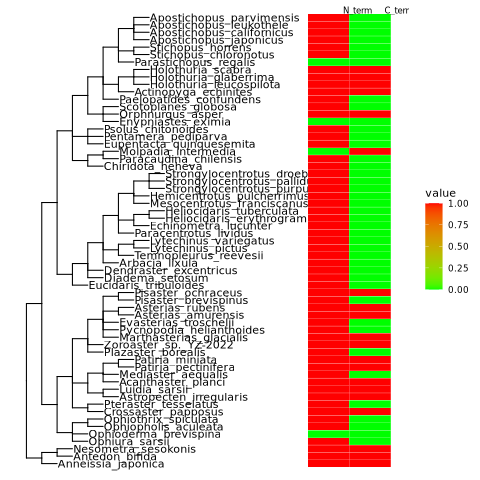

In [38]:
%%R -i df
# names(df)[names(df) == "Organism Name"] <- "Species_Name"
# df <- df[!duplicated(df$`Species_Name`), ]

# df$Species_Name <- gsub(" ", "_", df$Species_Name)
# df <- df %>% select(-Accession_ID)
df1 <- read.table("/gpfs/ilnitsky/NPM/results/df_echinoderm.tsv", header = TRUE, sep = "\t")
newick_tree <- "((((((((Apostichopus japonicus:1,Apostichopus californicus:1,Apostichopus leukothele:1,Apostichopus parvimensis:1)1:1,(Stichopus chloronotus:1,Stichopus horrens:1)1:1,Parastichopus regalis:1)1:1,((Holothuria leucospilota:1,Holothuria glaberrima:1,Holothuria scabra:1)1:1,Actinopyga echinites:1)1:1,Paelopatides confundens:1)1:1,(Enypniastes eximia:1,Orphnurgus asper:1,Scotoplanes globosa:1)1:1)1:1,((Paracaudina chilensis:1,Molpadia intermedia:1)1:1,Chiridota heheva:1)1:1,(Eupentacta quinquesemita:1,Pentamera pediparva:1,Psolus chitonoides:1)1:1)1:1,(((((Lytechinus pictus:1,Lytechinus variegatus:1)1:1,Temnopleurus reevesii:1)1:1,(((Heliocidaris erythrogramma:1,Heliocidaris tuberculata:1)1:1,Echinometra lucunter:1)1:1,((Strongylocentrotus purpuratus:1,Strongylocentrotus pallidus:1,Strongylocentrotus droebachiensis:1)1:1,Mesocentrotus franciscanus:1,Hemicentrotus pulcherrimus:1)1:1,Paracentrotus lividus:1)1:1,Arbacia lixula:1)1:1,Diadema setosum:1,Dendraster excentricus:1)1:1,Eucidaris tribuloides:1)1:1)1:1,(((((Patiria pectinifera:1,Patiria miniata:1)1:1,Acanthaster planci:1,Mediaster aequalis:1)1:1,(Astropecten irregularis:1,Luidia sarsii:1)1:1)1:1,(Crossaster papposus:1,Pteraster tesselatus:1)1:1,(((Asterias amurensis:1,Asterias rubens:1)1:1,(Pisaster brevispinus:1,Pisaster ochraceus:1)1:1,Marthasterias glacialis:1,Pycnopodia helianthoides:1,Evasterias troschelii:1)1:1,Plazaster borealis:1,Zoroaster sp. YZ-2022:1)1:1)1:1,((Ophiopholis aculeata:1,Ophiothrix spiculata:1)1:1,Ophiura sarsii:1,Ophioderma brevispina:1)1:1)1:1)1:1,((Antedon bifida:1,Nesometra sesokonis:1)1:1,Anneissia japonica:1)1:1);"
# newick_tree <- readLines("/home/ilnitsky/gpfs/NPM/ncbi_blast_search/my_tree.newick")
newick_tree <- gsub(" ", "_", newick_tree)
tree <- read.tree(text = newick_tree)

tree$tip.label 

plotTree <- ggtree(tree)
plotTree + geom_tiplab()

rownames(df1) <- trimws(df1$Species_Name)
df1$Species_Name <- NULL


p <- ggtree(tree) + geom_tiplab()
p <- gheatmap(p, df1, offset=8, width=0.6, colnames_position="top", hjust=-0.5, font.size=3)
# p <- p + scale_x_ggtree() 
print(p)
# print(tree$tip.label)

In [9]:
import os
import json
import pandas as pd

base_path = "/home/ilnitsky/NPM/genomes/echinodermata/"

organisms = os.listdir(base_path)
print(organisms)
data = []

for organism in organisms:
    file_path = os.path.join(base_path, organism, "ncbi_dataset/data/assembly_data_report.jsonl")
    if os.path.isfile(file_path):
        with open(file_path, 'r') as file:
            json_data = json.load(file)
            organism_name = json_data.get("organism", {}).get("organismName", "N/A")
            assembly_stats = json_data.get("assemblyStats", {})
            
            contigL50 = assembly_stats.get("contigL50", "N/A")
            contigN50 = assembly_stats.get("contigN50", "N/A")
            gcCount = assembly_stats.get("gcCount", "N/A")
            gcPercent = assembly_stats.get("gcPercent", "N/A")
            genomeCoverage = assembly_stats.get("genomeCoverage", "N/A")
            numberOfComponentSequences = assembly_stats.get("numberOfComponentSequences", "N/A")
            numberOfContigs = assembly_stats.get("numberOfContigs", "N/A")
            numberOfScaffolds = assembly_stats.get("numberOfScaffolds", "N/A")
            scaffoldL50 = assembly_stats.get("scaffoldL50", "N/A")
            scaffoldN50 = assembly_stats.get("scaffoldN50", "N/A")
            totalSequenceLength = assembly_stats.get("totalSequenceLength", "N/A")
            totalUngappedLength = assembly_stats.get("totalUngappedLength", "N/A")
            
            data.append({
                "organismName": organism_name,
                "contigL50": contigL50,
                "contigN50": contigN50,
                "gcCount": gcCount,
                "gcPercent": gcPercent,
                "genomeCoverage": genomeCoverage,
                "numberOfComponentSequences": numberOfComponentSequences,
                "numberOfContigs": numberOfContigs,
                "numberOfScaffolds": numberOfScaffolds,
                "scaffoldL50": scaffoldL50,
                "scaffoldN50": scaffoldN50,
                "totalSequenceLength": totalSequenceLength,
                "totalUngappedLength": totalUngappedLength
            })


df = pd.DataFrame(data)

print(df)

['Mesocentrotus_franciscanus', 'Strongylocentrotus_droebachiensis.zip', 'Paracentrotus_lividus', 'Eupentacta_quinquesemita', 'Lytechinus_pictus', 'Marthasterias_glacialis', 'Hemicentrotus_pulcherrimus', 'Eucidaris_tribuloides.zip', 'Paracaudina_chilensis', 'Temnopleurus_reevesii.zip', 'Apostichopus_leukothele', 'Psolus_chitonoides', 'Acanthaster_planci', 'Hemicentrotus_pulcherrimus.zip', 'Parastichopus_regalis', 'Actinopyga_echinites', 'Orphnurgus_asper', 'Crossaster_papposus', 'Holothuria_scabra', 'Paelopatides_confundens', 'Evasterias_troschelii', 'Acanthaster_planci.zip', 'Pycnopodia_helianthoides.zip', 'Stichopus_horrens', 'Pisaster_brevispinus.zip', 'Ophiura_sarsii', 'Ophiopholis_aculeata.zip', 'Paelopatides_confundens.zip', 'Marthasterias_glacialis.zip', 'Ophiothrix_spiculata', 'Pentamera_pediparva', 'Ophiopholis_aculeata', 'Heliocidaris_tuberculata.zip', 'Chiridota_heheva.zip', 'Pisaster_ochraceus', 'Holothuria_leucospilota.zip', 'Ophiura_sarsii.zip', 'Holothuria_glaberrima', 'A

In [10]:
df

,organismName,contigL50,contigN50,gcCount,gcPercent,genomeCoverage,numberOfComponentSequences,numberOfContigs,numberOfScaffolds,scaffoldL50,scaffoldN50,totalSequenceLength,totalUngappedLength
0,Mesocentrotus franciscanus,59062,2993,233529875,37.0,80.0x,166112,321183,166112,15,19908114,739864140,633441093
1,Paracentrotus lividus,6518,37479,319238647,36.5,80.0x,3747,51315,3747,9,41462573,927475755,879553267
2,Eupentacta quinquesemita,143847,2848,591637480,42.0,50.0x,651257,684434,651257,138238,2960,1404964302,1404512070
3,Lytechinus pictus,11,30022000,295397584,36.5,120.0x,368,391,368,8,35715200,811721768,811717168
4,Marthasterias glacialis,78,1872146,205649469,39.5,49.0x,106,574,106,9,25218880,520943681,520807681
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,Molpadia intermedia,87182,2240,272036208,37.0,105.0x,659491,671219,659491,83825,2298,734575371,733737141
57,Plazaster borealis,54,3100000,218058907,39.0,116.0x,801,1384,801,10,24975817,561050340,560758840
58,Patiria pectinifera,187,875000,248988863,40.5,40.0x,1480,2962,1480,9,25782902,615361208,614620208
59,Scotoplanes globosa,98594,2906,367259479,37.5,100.0x,511812,514428,511812,97646,2930,975746094,975603187
